In [2]:
import glob
import numpy as np
import scanpy as sc
import torch
import umap
import matplotlib.pyplot as plt

from mmidas.cplMixVAE import cpl_mixVAE
from mmidas.utils.cluster_analysis import K_selection
from mmidas.eval import summarize_inference
from mmidas.utils.config_tools import get_paths
from mmidas.utils.data_tools import load_data, get_loaders, generate_colors
from mmidas.utils.batch_removal import align_query


%load_ext autoreload
%autoreload 2

/Users/yeganeh.marghi/miniconda3/envs/mmidas/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
toml_file = 'pyproject.toml'
device = 'cpu'
config = get_paths(toml_file=toml_file)
data_file = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['anndata_file']
gene_file = config['paths']['main_dir'] / config['paths']['data_path'] / config['data']['hvg_file']
results_path = config['paths']['main_dir'] / config['paths']['saving_path']
available_models = glob.glob(str(results_path) + '/*')

/Users/yeganeh.marghi/github/LC-NE-MixRep/pyproject.toml
Getting files directories belong to data...
Getting files directories belong to models...


In [4]:
# load retroseq data
retor_file = config['paths']['main_dir'] / config['paths']['data_path'] / 'retroSeq.h5ad'
retro_ad = sc.read_h5ad(retor_file)
gene_id = retro_ad.var.index.values

In [5]:
old_data = load_data(file=data_file, gene_file=gene_file) 
ref_genes = old_data['gene_id']
ref_data = old_data['log1p']
n_gene = len(ref_genes)

Number of cells: 4608, Number of genes: 1827


In [6]:
# find genes are not in the reference gene list
missing_gene = list(set(ref_genes) - set(gene_id))
print('Missing genes: ', missing_gene)

exclucive_gene_idx = [np.where(ref_genes == gene)[0][0] for gene in missing_gene]
gene_idx = np.delete(np.arange(n_gene), exclucive_gene_idx)

# find index of genes 
gene_index = [np.where(gene_id == gene)[0][0] for gene in ref_genes if sum(gene_id == gene) > 0]

retro_data = dict()
retro_data['log1p'] = np.zeros((retro_ad.X.shape[0], n_gene))
retro_data['log1p'][:, gene_idx] = np.log1p(retro_ad.X[:, gene_index].toarray())
retro_data['gene_id'] = ref_genes
retro_data['cell_id'] = retro_ad.obs_names
print(retro_data['log1p'].shape)

Missing genes:  ['Gm35438 ENSMUSG00000118020', '4930517O19Rik', 'Gm11099']
(525, 1827)


In [ ]:
# convert data to torch
ref_data = torch.tensor(ref_data, dtype=torch.float32)
query_data = torch.tensor(retro_data['log1p'], dtype=torch.float32)
# Remove batch effect between AD and patchseq data
corrected_mtx = align_query(reference=ref_data, query=query_data, neighborhood_size=180, num_anchors=25, kernel_scale=1.0)

/var/folders/6y/lwqnjljs691fbrr_9gbqd31r0000gp/T/ipykernel_31142/1109690116.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ref_data = torch.tensor(ref_data, dtype=torch.float32)


Determining neighborhood...
Computing correction...      
Completed.                           


In [11]:
# Evaluate the alignment between AD and patchseq data
corrected_data = corrected_mtx.detach().numpy()
dataset_1 = np.concatenate((ref_data, retro_data['log1p']), axis=0)
dataset_2 = np.concatenate((ref_data, corrected_data), axis=0)
embedding_1 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=10, metric='euclidean').fit_transform(dataset_1)
embedding_2 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=10, metric='euclidean').fit_transform(dataset_2)

/Users/yeganeh.marghi/miniconda3/envs/mmidas/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/yeganeh.marghi/miniconda3/envs/mmidas/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


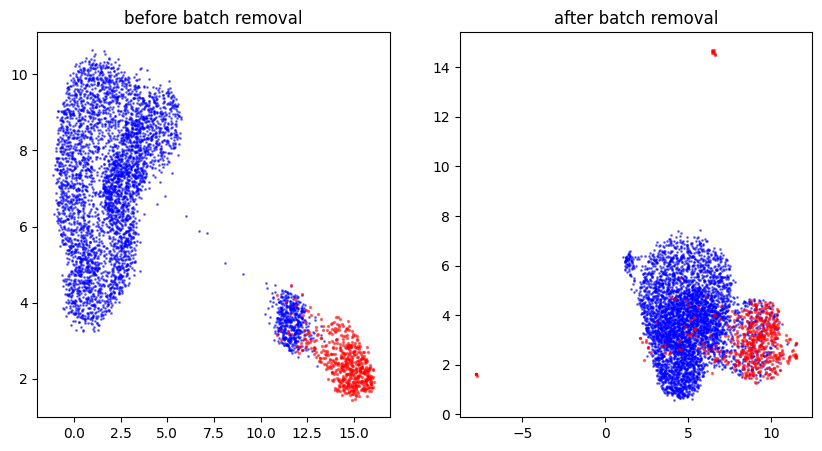

In [12]:
ref_samp_size = ref_data.shape[0]   
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(embedding_1[:ref_samp_size, 0], embedding_1[:ref_samp_size, 1], s=1, color='blue', alpha=0.5)
ax[0].scatter(embedding_1[ref_samp_size:, 0], embedding_1[ref_samp_size:, 1], s=2, color='red', alpha=.5)
ax[1].scatter(embedding_2[:ref_samp_size, 0], embedding_2[:ref_samp_size, 1], s=1, color='blue', alpha=0.5)
ax[1].scatter(embedding_2[ref_samp_size:, 0], embedding_2[ref_samp_size:, 1], s=2, color='red', alpha=.5)
ax[0].set_title('before batch removal')
ax[1].set_title('after batch removal')
plt.show()

In [ ]:
selected_model_file = available_models[0]
trained_models = glob.glob(selected_model_file + '/model/cpl_mixVAE_model_*')
# Get the model parameters from the selected model
param_vairables = selected_model_file.split('/')[-1].split('_')
params = {}
for p in range(0, len(param_vairables), 2):
    try:
        params[param_vairables[p]] = float(param_vairables[p+1])
        if params[param_vairables[p]] == int(params[param_vairables[p]]):
            params[param_vairables[p]] = int(params[param_vairables[p]])
    except ValueError:
        params[param_vairables[p]] = param_vairables[p+1]

In [ ]:
print('Initializing mixvae model ...')
mixvae = cpl_mixVAE(saving_folder=selected_model_file, device=device)
mixvae.init_model(
                n_categories=params['Cdim'],
                state_dim=params['Sdim'],
                input_dim=n_gene,
                fc_dim=params['fcdim'],
                lowD_dim=params['Zdim'],
                n_arm=params['narm'],
                tau=params['tau'],
                )

In [ ]:
ref_data_loader, _, _, _, _, _ = get_loaders(x=ref_data,batch_size=100)
retro_data_loader, _, _, _, _, _ = get_loaders(x=retro_data['log1p'],batch_size=100)

In [ ]:
model_order = 6
selected_model = glob.glob(selected_model_file + '/model/cpl_mixVAE_model_after_pruning_' + str(mixvae.n_categories - model_order) + '*')[0]
mixvae.variational = False
ref_outcome= summarize_inference(mixvae, selected_model, ref_data_loader)
retro_outcome = summarize_inference(mixvae, selected_model, retro_data_loader)

In [ ]:
for arm in range(params['narm']):
    print(f'Agreement for arm {arm}: ', np.sum(ref_outcome['pred_label'][arm]== retro_outcome['pred_label'][arm]) / len(ref_outcome['pred_label'][arm]))

print(f'Consensus between arms: ', np.sum(ref_outcome['pred_label'][0] == ref_outcome['pred_label'][1]) / len(ref_outcome['pred_label'][0]))
print(f'Consensus between corrected and reference data: ', np.sum(retro_outcome['pred_label'][0] == retro_outcome['pred_label'][1]) / len(retro_outcome['pred_label'][0]))